In [15]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 5)

In [16]:
pip install matplotlib seaborn


Note: you may need to restart the kernel to use updated packages.


In [2]:
import pandas as pd
import numpy as np
from pathlib import Path
import os

print("Working directory:", os.getcwd())

project_root = Path.cwd()
while not (project_root / 'data').exists() and project_root != project_root.parent:
    project_root = project_root.parent

print("Project root:", project_root)

data_path = project_root / 'data' / 'superstore.csv'
print("Loading from:", data_path)

df = pd.read_csv(data_path, encoding='latin-1')

print("\nShape:", df.shape)
print("\nColumns:", df.columns.tolist())
print("\nFirst 5 rows:")
print(df.head())

Working directory: C:\Users\rolan\OneDrive\Portafolio\ecommerce_sales\notebooks
Project root: C:\Users\rolan\OneDrive\Portafolio\ecommerce_sales
Loading from: C:\Users\rolan\OneDrive\Portafolio\ecommerce_sales\data\superstore.csv

Shape: (9994, 21)

Columns: ['Row ID', 'Order ID', 'Order Date', 'Ship Date', 'Ship Mode', 'Customer ID', 'Customer Name', 'Segment', 'Country', 'City', 'State', 'Postal Code', 'Region', 'Product ID', 'Category', 'Sub-Category', 'Product Name', 'Sales', 'Quantity', 'Discount', 'Profit']

First 5 rows:
   Row ID        Order ID  Order Date   Ship Date       Ship Mode Customer ID  \
0       1  CA-2016-152156   11/8/2016  11/11/2016    Second Class    CG-12520   
1       2  CA-2016-152156   11/8/2016  11/11/2016    Second Class    CG-12520   
2       3  CA-2016-138688   6/12/2016   6/16/2016    Second Class    DV-13045   
3       4  US-2015-108966  10/11/2015  10/18/2015  Standard Class    SO-20335   
4       5  US-2015-108966  10/11/2015  10/18/2015  Standard C

In [3]:
# Tipos de datos y valores nulos
print("=== INFO ===")
df.info()

print("\n=== NULOS POR COLUMNA ===")
print(df.isnull().sum())

print("\n=== DUPLICADOS ===")
print("Filas duplicadas:", df.duplicated().sum())

print("\n=== ESTADÍSTICAS NUMÉRICAS ===")
print(df.describe())

print("\n=== RANGO DE FECHAS ===")
print("Order Date min/max (raw):", df['Order Date'].min(), "→", df['Order Date'].max())
print("Ship Date  min/max (raw):", df['Ship Date'].min(),  "→", df['Ship Date'].max())

print("\n=== CATEGORÍAS ===")
print("Categories:", df['Category'].unique())
print("Sub-Categories:", df['Sub-Category'].nunique(), "unique")
print("Regions:", df['Region'].unique())
print("Segments:", df['Segment'].unique())
print("Ship Modes:", df['Ship Mode'].unique())

print("\n=== VALORES EXTREMOS ===")
print("Sales   min/max:", df['Sales'].min(), "→", df['Sales'].max())
print("Profit  min/max:", df['Profit'].min(), "→", df['Profit'].max())
print("Quantity min/max:", df['Quantity'].min(), "→", df['Quantity'].max())
print("Discount min/max:", df['Discount'].min(), "→", df['Discount'].max())

=== INFO ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row ID         9994 non-null   int64  
 1   Order ID       9994 non-null   object 
 2   Order Date     9994 non-null   object 
 3   Ship Date      9994 non-null   object 
 4   Ship Mode      9994 non-null   object 
 5   Customer ID    9994 non-null   object 
 6   Customer Name  9994 non-null   object 
 7   Segment        9994 non-null   object 
 8   Country        9994 non-null   object 
 9   City           9994 non-null   object 
 10  State          9994 non-null   object 
 11  Postal Code    9994 non-null   int64  
 12  Region         9994 non-null   object 
 13  Product ID     9994 non-null   object 
 14  Category       9994 non-null   object 
 15  Sub-Category   9994 non-null   object 
 16  Product Name   9994 non-null   object 
 17  Sales          9994 non-null   float64


In [4]:
# === LIMPIEZA ===

# 1. Convertir fechas a datetime
df['Order Date'] = pd.to_datetime(df['Order Date'])
df['Ship Date']  = pd.to_datetime(df['Ship Date'])

# 2. Postal Code como string (para no perder ceros a la izquierda)
df['Postal Code'] = df['Postal Code'].astype(str)

# 3. Crear columnas de tiempo útiles
df['Year']       = df['Order Date'].dt.year
df['Month']      = df['Order Date'].dt.month
df['YearMonth']  = df['Order Date'].dt.to_period('M').astype(str)
df['DayOfWeek']  = df['Order Date'].dt.day_name()
df['Quarter']    = df['Order Date'].dt.quarter

# 4. Días de envío (Ship Date - Order Date)
df['ShipDays'] = (df['Ship Date'] - df['Order Date']).dt.days

# 5. Verificar el rango real ahora que las fechas son datetime
print("Periodo real:", df['Order Date'].min().date(), "→", df['Order Date'].max().date())
print("Años presentes:", sorted(df['Year'].unique()))
print("Días de envío → min/max/promedio:",
      df['ShipDays'].min(),
      df['ShipDays'].max(),
      round(df['ShipDays'].mean(), 2))

# 6. Vista final
print("\nShape final:", df.shape)
print("\nNuevas columnas:", ['Year','Month','YearMonth','DayOfWeek','Quarter','ShipDays'])
print("\nPrimeras filas con fechas ya convertidas:")
print(df[['Order Date','Ship Date','Year','Month','YearMonth','ShipDays']].head())

Periodo real: 2014-01-03 → 2017-12-30
Años presentes: [np.int32(2014), np.int32(2015), np.int32(2016), np.int32(2017)]
Días de envío → min/max/promedio: 0 7 3.96

Shape final: (9994, 27)

Nuevas columnas: ['Year', 'Month', 'YearMonth', 'DayOfWeek', 'Quarter', 'ShipDays']

Primeras filas con fechas ya convertidas:
  Order Date  Ship Date  Year  Month YearMonth  ShipDays
0 2016-11-08 2016-11-11  2016     11   2016-11         3
1 2016-11-08 2016-11-11  2016     11   2016-11         3
2 2016-06-12 2016-06-16  2016      6   2016-06         4
3 2015-10-11 2015-10-18  2015     10   2015-10         7
4 2015-10-11 2015-10-18  2015     10   2015-10         7


In [5]:
df.to_csv(project_root / 'data' / 'clean.csv', index=False)

In [6]:
# Guardar versión limpia para el siguiente notebook (02_eda)
output_path = project_root / 'data' / 'clean.csv'
df.to_csv(output_path, index=False)

print("Guardado en:", output_path)
print("Filas:", len(df), "| Columnas:", df.shape[1])

Guardado en: C:\Users\rolan\OneDrive\Portafolio\ecommerce_sales\data\clean.csv
Filas: 9994 | Columnas: 27


In [7]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 5)

C:\Users\rolan\AppData\Local\Temp\ipykernel_8600\323052795.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=yearly, x='Year', y='Sales', ax=ax[0], palette='Blues_d')
C:\Users\rolan\AppData\Local\Temp\ipykernel_8600\323052795.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=yearly, x='Year', y='Profit', ax=ax[1], palette='Greens_d')


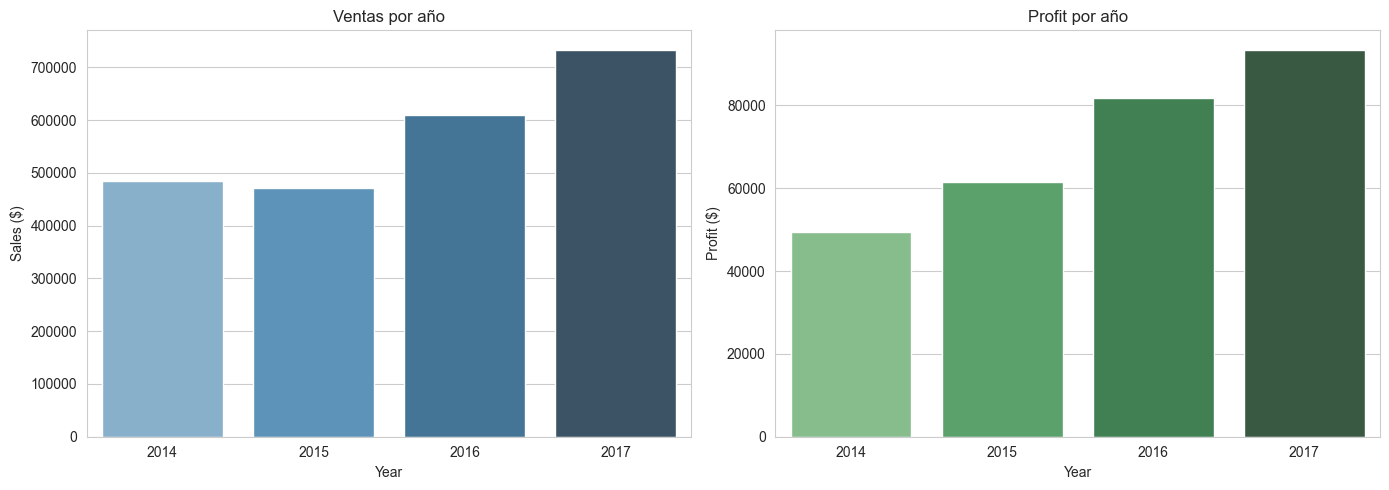

   Year        Sales      Profit
0  2014  484247.4981  49543.9741
1  2015  470532.5090  61618.6037
2  2016  609205.5980  81795.1743
3  2017  733215.2552  93439.2696


In [20]:
yearly = df.groupby('Year').agg(
    Sales=('Sales','sum'),
    Profit=('Profit','sum')
).reset_index()

fig, ax = plt.subplots(1, 2, figsize=(14, 5))

sns.barplot(data=yearly, x='Year', y='Sales', ax=ax[0], palette='Blues_d')
ax[0].set_title('Ventas por año')
ax[0].set_ylabel('Sales ($)')

sns.barplot(data=yearly, x='Year', y='Profit', ax=ax[1], palette='Greens_d')
ax[1].set_title('Profit por año')
ax[1].set_ylabel('Profit ($)')

plt.tight_layout()
plt.show()

print(yearly)

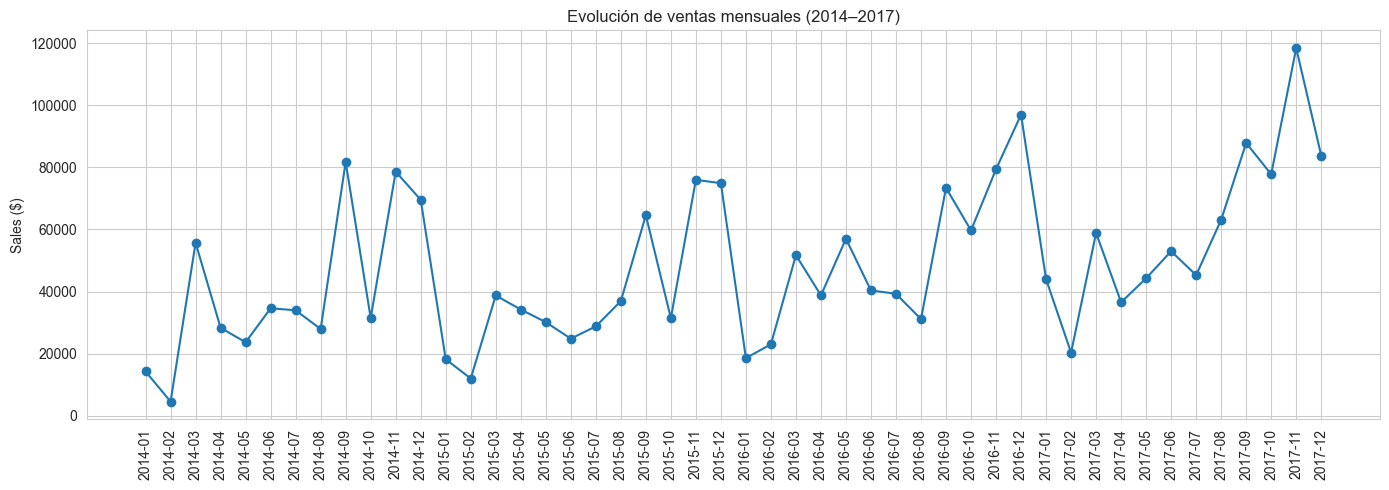

In [9]:
monthly = df.groupby('YearMonth')['Sales'].sum().reset_index()

plt.figure(figsize=(14, 5))
plt.plot(monthly['YearMonth'], monthly['Sales'], marker='o', linewidth=1.5)
plt.xticks(rotation=90)
plt.title('Evolución de ventas mensuales (2014–2017)')
plt.ylabel('Sales ($)')
plt.xlabel('')
plt.tight_layout()
plt.show()

In [ ]:
top_sales  = df.groupby('Sub-Category')['Sales'].sum().nlargest(10).reset_index()
top_profit = df.groupby('Sub-Category')['Profit'].sum().nlargest(10).reset_index()

fig, ax = plt.subplots(1, 2, figsize=(14, 5))

sns.barplot(data=top_sales, y='Sub-Category', x='Sales', ax=ax[0], palette='Blues_d')
ax[0].set_title('Top 10 Sub-Categorías por Ventas')

sns.barplot(data=top_profit, y='Sub-Category', x='Profit', ax=ax[1], palette='Greens_d')
ax[1].set_title('Top 10 Sub-Categorías por Profit')

plt.tight_layout()
plt.show()

C:\Users\rolan\AppData\Local\Temp\ipykernel_8600\143692908.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top_sales, y='Sub-Category', x='Sales', ax=ax[0], palette='Blues_d')
C:\Users\rolan\AppData\Local\Temp\ipykernel_8600\143692908.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top_profit, y='Sub-Category', x='Profit', ax=ax[1], palette='Greens_d')


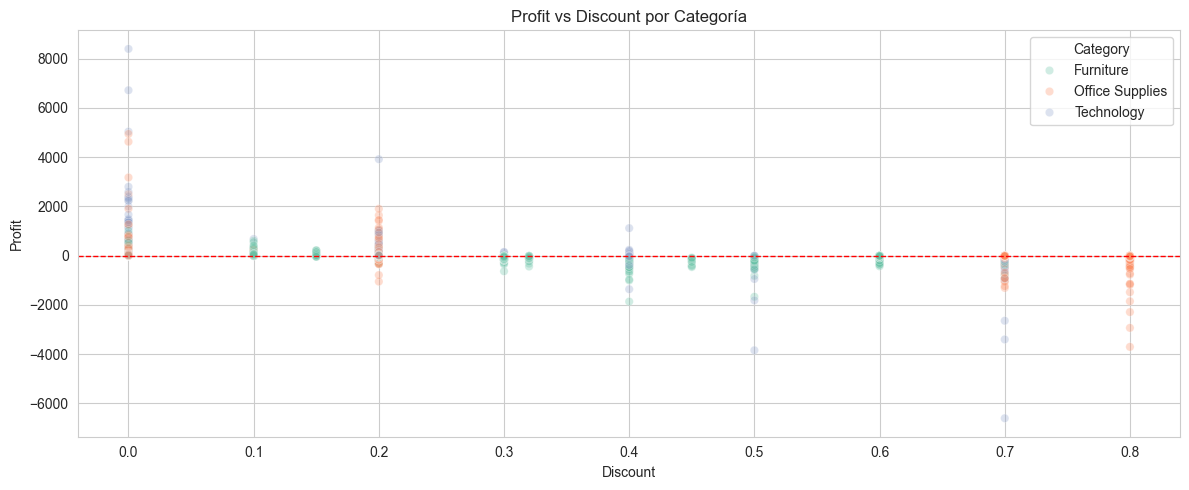

In [11]:
plt.figure(figsize=(12, 5))

sns.scatterplot(data=df, x='Discount', y='Profit',
                alpha=0.3, hue='Category', palette='Set2')

plt.axhline(0, color='red', linestyle='--', linewidth=1)
plt.title('Profit vs Discount por Categoría')
plt.tight_layout()
plt.show()

In [18]:
# Profit por categoría
cat_profit = df.groupby('Category').agg(
    Sales=('Sales', 'sum'),
    Profit=('Profit', 'sum'),
    Margen=('Profit', lambda x: x.sum() / df.loc[x.index, 'Sales'].sum() * 100)
).reset_index()
cat_profit['Margen'] = cat_profit['Margen'].round(2)

print("=== Profit por Categoría ===")
print(cat_profit)

# Sub-categorías con pérdidas
subcat = df.groupby('Sub-Category').agg(
    Sales=('Sales', 'sum'),
    Profit=('Profit', 'sum')
).reset_index().sort_values('Profit')

print("\n=== Sub-categorías con PÉRDIDAS ===")
print(subcat[subcat['Profit'] < 0])

# Top descuentos y su impacto
print("\n=== Impacto del descuento ===")
df['DiscountBand'] = pd.cut(df['Discount'],
                             bins=[-0.01, 0, 0.2, 0.3, 0.5, 1],
                             labels=['0%', '1-20%', '21-30%', '31-50%', '>50%'])

discount_impact = df.groupby('DiscountBand', observed=True).agg(
    Orders=('Order ID', 'count'),
    Sales=('Sales', 'sum'),
    Profit=('Profit', 'sum'),
    Margen=('Profit', lambda x: x.sum() / df.loc[x.index, 'Sales'].sum() * 100)
).round(2)

print(discount_impact)

=== Profit por Categoría ===
          Category        Sales       Profit  Margen
0        Furniture  741999.7953   18451.2728    2.49
1  Office Supplies  719047.0320  122490.8008   17.04
2       Technology  836154.0330  145454.9481   17.40

=== Sub-categorías con PÉRDIDAS ===
   Sub-Category        Sales      Profit
16       Tables  206965.5320 -17725.4811
4     Bookcases  114879.9963  -3472.5560
15     Supplies   46673.5380  -1189.0995

=== Impacto del descuento ===
              Orders       Sales     Profit  Margen
DiscountBand                                       
0%              4798  1087908.47  320987.60   29.51
1-20%           3803   846522.24  100785.47   11.91
21-30%           227   103226.66  -10369.28  -10.05
31-50%           310   195314.76  -48447.73  -24.80
>50%             856    64228.74  -76559.05 -119.20


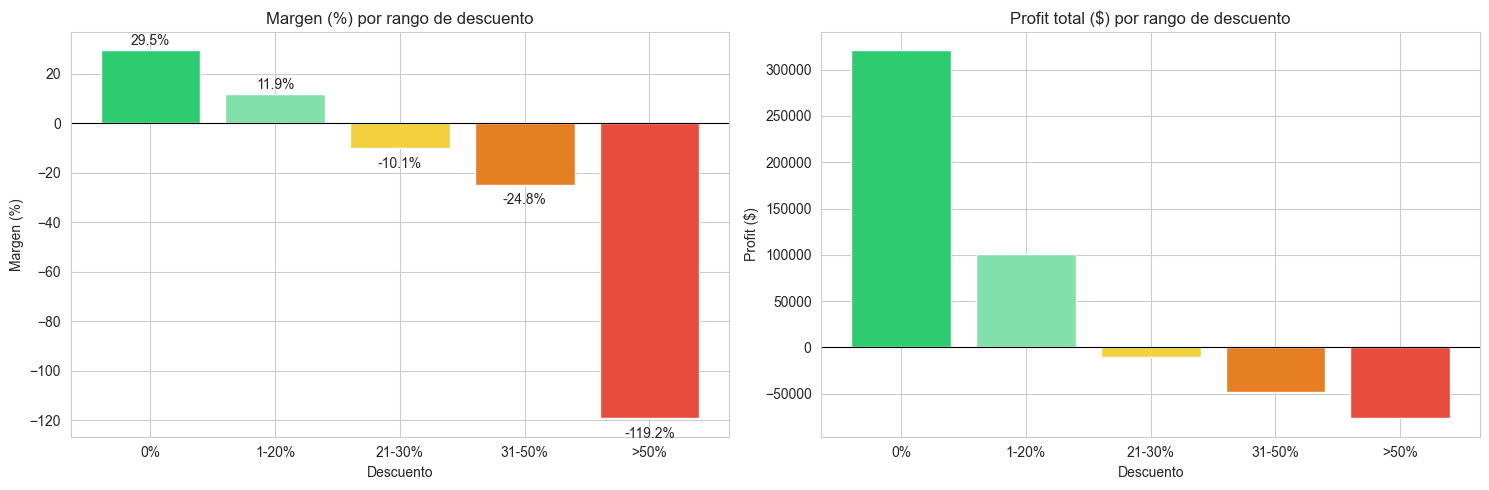

In [19]:
# Visualización: el descuento mata el profit
fig, ax = plt.subplots(1, 2, figsize=(15, 5))

# Margen por banda de descuento
colors = ['#2ecc71', '#82e0aa', '#f4d03f', '#e67e22', '#e74c3c']
bars = ax[0].bar(discount_impact.index.astype(str),
                  discount_impact['Margen'],
                  color=colors)
ax[0].axhline(0, color='black', linewidth=0.8)
ax[0].set_title('Margen (%) por rango de descuento')
ax[0].set_ylabel('Margen (%)')
ax[0].set_xlabel('Descuento')
for bar, val in zip(bars, discount_impact['Margen']):
    ax[0].text(bar.get_x() + bar.get_width()/2,
               val + (2 if val > 0 else -8),
               f'{val:.1f}%', ha='center', fontsize=10)

# Profit por banda
bars2 = ax[1].bar(discount_impact.index.astype(str),
                   discount_impact['Profit'],
                   color=colors)
ax[1].axhline(0, color='black', linewidth=0.8)
ax[1].set_title('Profit total ($) por rango de descuento')
ax[1].set_ylabel('Profit ($)')
ax[1].set_xlabel('Descuento')

plt.tight_layout()
plt.show()